In [1]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import time
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from matplotlib import pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"keshrivishal21","key":"4c8bb86460f4dd386e694fd83bc26447"}'}

In [3]:
!mkdir -p ~/.config/kaggle
!mv kaggle.json ~/.config/kaggle/
!chmod 600 ~/.config/kaggle/kaggle.json

In [4]:
!kaggle competitions download -c state-farm-distracted-driver-detection

100% 4.00G/4.00G [00:18<00:00, 237MB/s]



In [5]:
!unzip -q state-farm-distracted-driver-detection.zip -d data

In [6]:
df = pd.read_csv("/content/data/driver_imgs_list.csv")
df.head()

,subject,classname,img
0,p002,c0,img_44733.jpg
1,p002,c0,img_72999.jpg
2,p002,c0,img_25094.jpg
3,p002,c0,img_69092.jpg
4,p002,c0,img_92629.jpg


In [7]:
drivers = df['subject'].unique()
print("Total drivers:", len(drivers))

Total drivers: 26


In [8]:
train_drivers, temp_drivers = train_test_split(
    drivers,
    test_size=0.4,
    random_state=42
)

val_drivers, test_drivers = train_test_split(
    temp_drivers,
    test_size=0.5,
    random_state=42
)

print("Train drivers:", len(train_drivers))
print("Val drivers:", len(val_drivers))
print("Test drivers:", len(test_drivers))

Train drivers: 15
Val drivers: 5
Test drivers: 6


In [9]:
train_df = df[df['subject'].isin(train_drivers)]
val_df = df[df['subject'].isin(val_drivers)]
test_df = df[df['subject'].isin(test_drivers)]

print(train_df['subject'].nunique())
print(val_df['subject'].nunique())
print(test_df['subject'].nunique())

15
5
6


In [10]:
base_path = "/content/data/imgs/train"

def add_image_path(df):
    return df.apply(
        lambda row: os.path.join(base_path, row['classname'], row['img']),
        axis=1
    )

train_paths = add_image_path(train_df)
val_paths = add_image_path(val_df)
test_paths = add_image_path(test_df)

train_labels = train_df['classname']
val_labels = val_df['classname']
test_labels = test_df['classname']

In [11]:
le = LabelEncoder()
train_labels = le.fit_transform(train_labels)
val_labels = le.transform(val_labels)
test_labels = le.transform(test_labels)

In [12]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
tf.random.set_seed(42)

def process_image_roi(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    h = tf.shape(image)[0]
    w = tf.shape(image)[1]

    # 🔥 Controlled ROI jitter (important)
    shift_h = tf.random.uniform([], -0.02, 0.02)
    shift_w = tf.random.uniform([], -0.04, 0.04)

    top = tf.cast((0.45 + shift_h) * tf.cast(h, tf.float32), tf.int32)
    bottom = tf.cast(0.95 * tf.cast(h, tf.float32), tf.int32)
    left = tf.cast((0.30 + shift_w) * tf.cast(w, tf.float32), tf.int32)
    right = tf.cast(0.75 * tf.cast(w, tf.float32), tf.int32)

    roi = image[top:bottom, left:right]

    roi = tf.image.resize(roi, IMG_SIZE)
    roi = tf.cast(roi, tf.float32)

    return roi, label

def create_dataset_roi(paths, labels, shuffle=True):

    labels = tf.one_hot(labels, depth=10)

    ds = tf.data.Dataset.from_tensor_slices((paths.values, labels))

    if shuffle:
        ds = ds.shuffle(3000)   # 🔥 bigger buffer

    ds = ds.map(process_image_roi, num_parallel_calls=tf.data.AUTOTUNE)

    # 🔥 cache (disk-safe for colab)
    ds = ds.cache('/tmp/roi_cache')

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    # 🔥 pipeline optimization
    options = tf.data.Options()
    options.experimental_deterministic = False
    ds = ds.with_options(options)

    return ds

train_ds = create_dataset_roi(train_paths, train_labels, True)
val_ds   = create_dataset_roi(val_paths, val_labels, False)
test_ds  = create_dataset_roi(test_paths, test_labels, False)

In [14]:
for path in train_paths[:5]:
    print(path, os.path.exists(path))

/content/data/imgs/train/c0/img_48693.jpg True
/content/data/imgs/train/c0/img_44903.jpg True
/content/data/imgs/train/c0/img_58514.jpg True
/content/data/imgs/train/c0/img_62307.jpg True
/content/data/imgs/train/c0/img_83984.jpg True


In [15]:
set(train_drivers) & set(val_drivers)
set(train_drivers) & set(test_drivers)
set(val_drivers) & set(test_drivers)

set()

In [16]:
for images, labels in train_ds.take(1):
    print("Batch shape:", images.shape)

Batch shape: (32, 224, 224, 3)


In [17]:
print("Train images:", len(train_paths))
print("Val images:", len(val_paths))
print("Test images:", len(test_paths))

Train images: 13440
Val images: 3312
Test images: 5672


In [18]:
def custom_mobilenet_style(input_shape=(224,224,3), num_classes=10):

    inputs = tf.keras.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = tf.keras.layers.Rescaling(1./255)(x)

    # -------- Block 1 --------
    x = tf.keras.layers.Conv2D(32, 3, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # -------- Block 2 --------
    x = tf.keras.layers.SeparableConv2D(64, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # -------- Block 3 --------
    x = tf.keras.layers.SeparableConv2D(128, 3, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # -------- Block 4 --------
    x = tf.keras.layers.SeparableConv2D(128, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # -------- Block 5 --------
    x = tf.keras.layers.SeparableConv2D(256, 3, strides=2, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # -------- Block 6 --------
    x = tf.keras.layers.SeparableConv2D(256, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # -------- Head --------
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

In [19]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    min_delta=1e-3
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1),
])

In [20]:
model = custom_mobilenet_style()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 112, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 112, 112, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 56, 56, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 56, 56, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 28, 28, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 28, 28, 256)    │        68,096 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 256)    │         1,02

 Total params: 203,946 (796.66 KB)

 Trainable params: 202,218 (789.91 KB)

 Non-trainable params: 1,728 (6.75 KB)

In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=90,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/90
420/420 ━━━━━━━━━━━━━━━━━━━━ 148s 257ms/step - accuracy: 0.1625 - loss: 2.2579 - val_accuracy: 0.1106 - val_loss: 2.3291 - learning_rate: 1.0000e-04
Epoch 2/90
420/420 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.2545 - loss: 2.1121 - val_accuracy: 0.2236 - val_loss: 2.2116 - learning_rate: 1.0000e-04
Epoch 3/90
420/420 ━━━━━━━━━━━━━━━━━━━━ 45s 108ms/step - accuracy: 0.3238 - loss: 1.9527 - val_accuracy: 0.2482 - val_loss: 2.1235 - learning_rate: 1.0000e-04
Epoch 4/90
420/420 ━━━━━━━━━━━━━━━━━━━━ 80s 103ms/step - accuracy: 0.3847 - loss: 1.8210 - val_accuracy: 0.3705 - val_loss: 1.9441 - learning_rate: 1.0000e-04
Epoch 5/90
420/420 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.4414 - loss: 1.7120 - val_accuracy: 0.3972 - val_loss: 1.8693 - learning_rate: 1.0000e-04
Epoch 6/90
420/420 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - accuracy: 0.4841 - loss: 1.6265 - val_accuracy: 0.3804 - val_loss: 1.8517 - learning_rate: 1.0000e-04
Epoch 7/90
420/420 ━━━━━━━━━━━━━━━━━━━━ 45s 1

In [22]:
model.save("/content/data/models/final_model.keras")

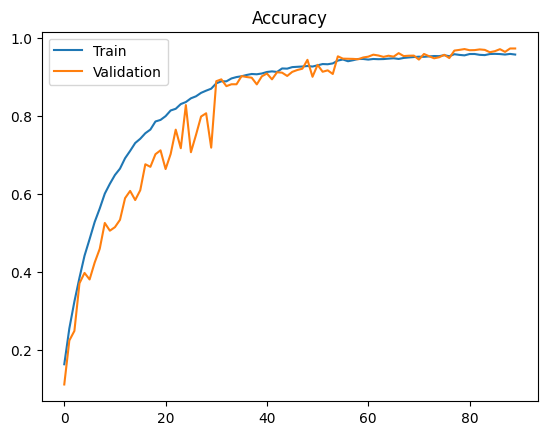

In [23]:
# Accuracy curve
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

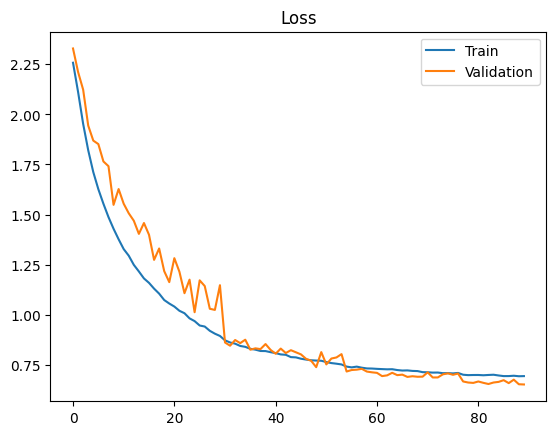

In [24]:
# Loss curve
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')
plt.show()

In [25]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

178/178 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9744 - loss: 0.6411
Test Accuracy: 0.9743679761886597


In [26]:
import time
import numpy as np

sample_batch = next(iter(test_ds))[0]

start = time.time()
pred = model.predict(sample_batch)
end = time.time()

time_per_image = (end - start) / len(sample_batch)
print("Time per image (seconds):", time_per_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
Time per image (seconds): 0.016168974339962006


In [27]:
time_per_image = time_per_image * 1000
print("Time per image (milliseconds):", time_per_image)

Time per image (milliseconds): 16.168974339962006


In [28]:
y_true = []
y_pred = []

for batch_x, batch_y in test_ds:
    preds = model(batch_x, training=False)

    y_true.append(tf.argmax(batch_y, axis=1))
    y_pred.append(tf.argmax(preds, axis=1))

y_true = tf.concat(y_true, axis=0).numpy()
y_pred = tf.concat(y_pred, axis=0).numpy()

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1424    2    0    3   13    8    1    0    4   13]
 [   5 1310    0    0    1    0    0    1    0   10]
 [   3    2 1358    0    4    3    4    1   11    0]
 [  13    0    0 1346   24    1    0    0    1    2]
 [  11    0    0    3 1329    3    0    2    5    1]
 [   4    0    0    0    3 1365    0    1    1    2]
 [   4    1    3    0    3    1 1334    3   33    5]
 [   0    0    0    1    0    0    0 1198    3    4]
 [   8    2    5    0    2    3   15    9 1166   15]
 [   6    3    0    2    4    5    7    0    6 1291]]


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.976264880952381
Precision: 0.9764096393352879
Recall: 0.976264880952381
F1-score: 0.9762875667875972


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

          c0       0.96      0.97      0.97      1468
          c1       0.99      0.99      0.99      1327
          c2       0.99      0.98      0.99      1386
          c3       0.99      0.97      0.98      1387
          c4       0.96      0.98      0.97      1354
          c5       0.98      0.99      0.99      1376
          c6       0.98      0.96      0.97      1387
          c7       0.99      0.99      0.99      1206
          c8       0.95      0.95      0.95      1225
          c9       0.96      0.98      0.97      1324

    accuracy                           0.98     13440
   macro avg       0.98      0.98      0.98     13440
weighted avg       0.98      0.98      0.98     13440



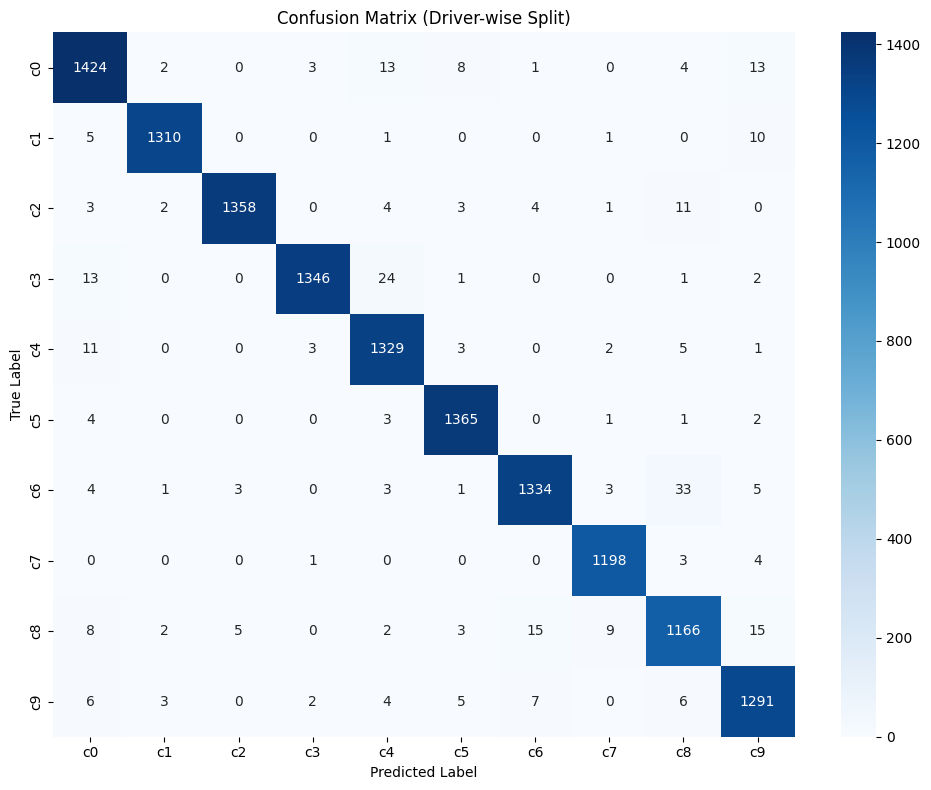

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = le.classes_

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (Driver-wise Split)")

plt.tight_layout()
plt.show()

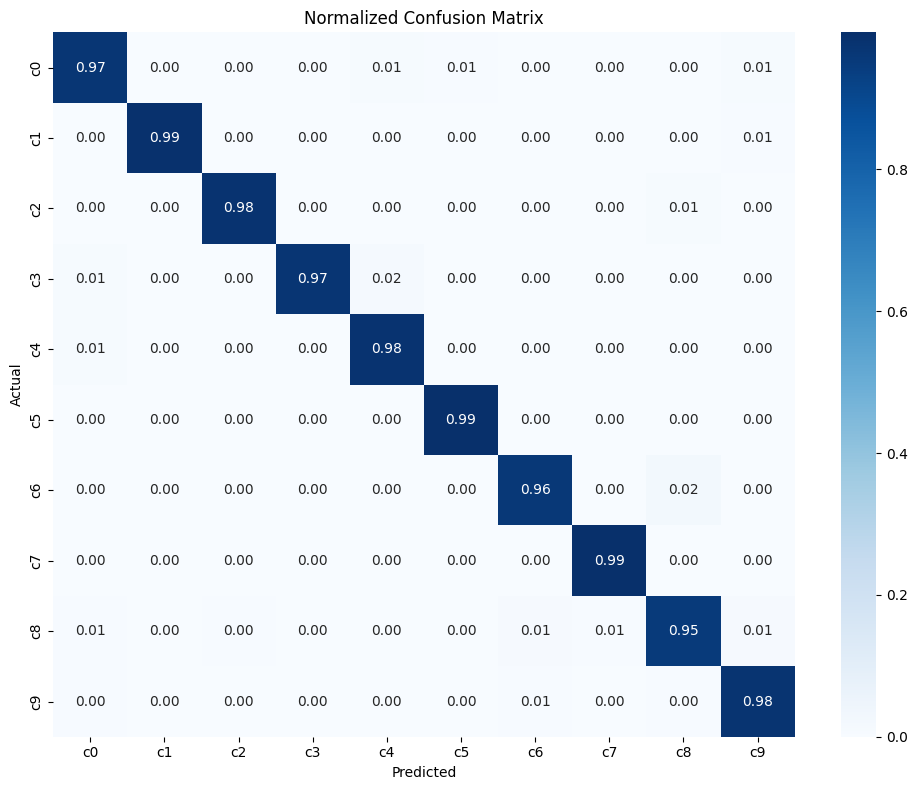

In [33]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10,8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [34]:
print("Macro Precision:", precision_score(y_true, y_pred, average='macro'))
print("Macro Recall:", recall_score(y_true, y_pred, average='macro'))
print("Macro F1:", f1_score(y_true, y_pred, average='macro'))

Macro Precision: 0.9762483701298708
Macro Recall: 0.9763062973305022
Macro F1: 0.9762284878925559
